In [1]:
!pip install opendatasets

name : vaibhav7312005

passcode : KGAT_a8b29f6f078c8f9577bde272bf3a4662

In [2]:
import opendatasets as od
od.download("https://www.kaggle.com/datasets/sriramr/fruits-fresh-and-rotten-for-classification")

Please provide your Kaggle credentials to download this dataset. Learn more: http://bit.ly/kaggle-creds
Your Kaggle username:

  vaibhav7312005


Your Kaggle Key:

  ········


Dataset URL: https://www.kaggle.com/datasets/sriramr/fruits-fresh-and-rotten-for-classification


100%|██████████| 3.58G/3.58G [01:32<00:00, 41.5MB/s]


In [3]:
import os

data_dir ="./fruits-fresh-and-rotten-for-classification/dataset/train"
classes = os.listdir(data_dir)

for cls in classes :
  count = len(os.listdir(os.path.join(data_dir , cls)))
  print(f"{cls}: {count} images")

rottenoranges: 1595 images
rottenbanana: 2224 images
freshbanana: 1581 images
freshoranges: 1466 images
freshapples: 1693 images
rottenapples: 2342 images


# Augmentaion
-> already occur in images

In [4]:
!pip install tensorflow


In [5]:
import os
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
from tensorflow.keras.preprocessing.image import ImageDataGenerator

2026-04-07 21:04:02.209123: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1775595842.639742      55 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1775595842.741700      55 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1775595843.753502      55 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1775595843.753536      55 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1775595843.753539      55 computation_placer.cc:177] computation placer alr

In [6]:
TRAIN_DIR = "./fruits-fresh-and-rotten-for-classification/dataset/train"
TEST_DIR = "./fruits-fresh-and-rotten-for-classification/dataset/test"

IMG_SIZE =(224,224)
BATCH_SIZE = 32
CLASSES = 6


# we do not use any augmentation beacuse data is already 

In [7]:
datagen = ImageDataGenerator(
    rescale = 1.0 / 255,
    validation_split = 0.2
)

In [8]:
train_data = datagen.flow_from_directory(
    TRAIN_DIR,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    subset='training'
)

val_data = datagen.flow_from_directory(
    TEST_DIR,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    subset='validation')


Found 8723 images belonging to 6 classes.
Found 538 images belonging to 6 classes.


In [1]:
# Get class labels and their corresponding names

print("classes\n" , train_data.class_indices)




# Get the labels for all images in train_data
labels = train_data.classes
print(labels)

NameError: name 'train_data' is not defined

In [10]:
model = keras.Sequential([

    # ── Block 1 ──────────────────────────
    layers.Conv2D(32, (3, 3), activation="relu",
                  input_shape=(IMG_SIZE[0], IMG_SIZE[1], 3)),
    layers.BatchNormalization(),
    layers.MaxPooling2D(2, 2),

    # ── Block 2 ──────────────────────────
    layers.Conv2D(64, (3, 3), activation="relu"),
    layers.BatchNormalization(),
    layers.MaxPooling2D(2, 2),

    # ── Block 3 ──────────────────────────
    layers.Conv2D(128, (3, 3), activation="relu"),
    layers.BatchNormalization(),
    layers.MaxPooling2D(2, 2),

    # ── Block 4 ──────────────────────────
    layers.Conv2D(256, (3, 3), activation="relu"),
    layers.BatchNormalization(),
    layers.MaxPooling2D(2, 2),

    # ── Flatten + Dense Head ─────────────
    layers.Flatten(),

    layers.Dense(512, activation="relu"),
    layers.Dropout(0.5),        # prevent overfitting
    layers.Dense(256, activation="relu"),
    layers.Dropout(0.3),

    # ── Output Layer ─────────────────────
    layers.Dense(train_data.num_classes, activation='softmax')  # sigmoid for binary classification
])

model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)
I0000 00:00:1775595870.056123      55 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 15511 MB memory:  -> device: 0, name: Tesla P100-PCIE-16GB, pci bus id: 0000:00:04.0, compute capability: 6.0


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 222, 222, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 222, 222, 32)   │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 111, 111, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 109, 109, 64)   │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 109, 109, 64)   │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 54, 54, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 52, 52, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 52, 52, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 26, 26, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 24, 24, 256)    │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 24, 24, 256)    │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 12, 12, 256)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 36864)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 512)            │    18,874,880 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 256)            │       131,328 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 6)              │         1,542 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 19,398,086 (74.00 MB)

 Trainable params: 19,397,126 (73.99 MB)

 Non-trainable params: 960 (3.75 KB)

In [11]:
model.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

In [12]:
callbacks = [
    # Save best model automatically
    keras.callbacks.ModelCheckpoint(
        filepath        = "best_catdog_model.keras",
        monitor         = "val_accuracy",
        save_best_only  = True,
        verbose         = 1
    ),
    # Stop early if model stops improving
    keras.callbacks.EarlyStopping(
        monitor   = "val_loss",
        patience  = 5,           # wait 5 epochs before stopping
        verbose   = 1,
        restore_best_weights = True
    ),
    # Reduce learning rate when stuck
    keras.callbacks.ReduceLROnPlateau(
        monitor  = "val_loss",
        factor   = 0.5,
        patience = 3,
        verbose  = 1
    )
]

In [13]:
history = model.fit(
    train_data,                               # augmented training data
    steps_per_epoch  = train_data.samples // BATCH_SIZE,
    epochs           = 15,
    validation_data  = val_data,             # test data for validation
    validation_steps = val_data.samples  // BATCH_SIZE,
    callbacks        = callbacks,
    verbose          = 1
)

/usr/local/lib/python3.12/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


Epoch 1/15


I0000 00:00:1775595875.386536     155 service.cc:152] XLA service 0x7b2450006380 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1775595875.386570     155 service.cc:160]   StreamExecutor device (0): Tesla P100-PCIE-16GB, Compute Capability 6.0
I0000 00:00:1775595876.130544     155 cuda_dnn.cc:529] Loaded cuDNN version 91002


  1/272 ━━━━━━━━━━━━━━━━━━━━ 49:36 11s/step - accuracy: 0.0938 - loss: 4.3993

I0000 00:00:1775595883.119091     155 device_compiler.h:188] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


272/272 ━━━━━━━━━━━━━━━━━━━━ 0s 134ms/step - accuracy: 0.5935 - loss: 6.5851
Epoch 1: val_accuracy improved from -inf to 0.47656, saving model to best_catdog_model.keras
272/272 ━━━━━━━━━━━━━━━━━━━━ 52s 152ms/step - accuracy: 0.5937 - loss: 6.5766 - val_accuracy: 0.4766 - val_loss: 3.7381 - learning_rate: 0.0010
Epoch 2/15
  1/272 ━━━━━━━━━━━━━━━━━━━━ 10s 39ms/step - accuracy: 0.7812 - loss: 1.1383

/usr/local/lib/python3.12/dist-packages/keras/src/trainers/epoch_iterator.py:116: UserWarning: Your input ran out of data; interrupting training. Make sure that your dataset or generator can generate at least `steps_per_epoch * epochs` batches. You may need to use the `.repeat()` function when building your dataset.
  self._interrupted_warning()



Epoch 2: val_accuracy improved from 0.47656 to 0.52148, saving model to best_catdog_model.keras
272/272 ━━━━━━━━━━━━━━━━━━━━ 4s 13ms/step - accuracy: 0.7812 - loss: 1.1383 - val_accuracy: 0.5215 - val_loss: 3.4144 - learning_rate: 0.0010
Epoch 3/15
272/272 ━━━━━━━━━━━━━━━━━━━━ 0s 115ms/step - accuracy: 0.7702 - loss: 1.3616
Epoch 3: val_accuracy improved from 0.52148 to 0.77539, saving model to best_catdog_model.keras
272/272 ━━━━━━━━━━━━━━━━━━━━ 35s 127ms/step - accuracy: 0.7703 - loss: 1.3610 - val_accuracy: 0.7754 - val_loss: 0.8859 - learning_rate: 0.0010
Epoch 4/15
  1/272 ━━━━━━━━━━━━━━━━━━━━ 10s 40ms/step - accuracy: 0.7188 - loss: 0.6122
Epoch 4: val_accuracy improved from 0.77539 to 0.77734, saving model to best_catdog_model.keras
272/272 ━━━━━━━━━━━━━━━━━━━━ 3s 12ms/step - accuracy: 0.7188 - loss: 0.6122 - val_accuracy: 0.7773 - val_loss: 0.9113 - learning_rate: 0.0010
Epoch 5/15
272/272 ━━━━━━━━━━━━━━━━━━━━ 0s 115ms/step - accuracy: 0.8177 - loss: 0.8184
Epoch 5: val_accura

In [14]:
loss, acc = model.evaluate(val_data)
print("Validation Accuracy:", acc)

17/17 ━━━━━━━━━━━━━━━━━━━━ 3s 204ms/step - accuracy: 0.9500 - loss: 0.1879
Validation Accuracy: 0.9535316228866577


In [2]:
from tensorflow.keras.models import load_model

model = load_model("best_catdog_model.keras")

2026-04-08 15:36:20.678419: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1775662580.958810      55 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1775662581.038487      55 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1775662581.636547      55 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1775662581.636603      55 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1775662581.636606      55 computation_placer.cc:177] computation placer alr

ValueError: File not found: filepath=best_catdog_model.keras. Please ensure the file is an accessible `.keras` zip file.

# EVEN THOUGH THERE IS NO NEED FOR TRASNFER LEARINNG BUT I HAVE TO PRACTICE SO I AM GOING TO USE mobielnetv2


In [ ]:
# ── Step 1: Import what we need ──────────────────────────────
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras import layers, models

In [ ]:
# ── Step 2: Load the pretrained base ─────────────────────────

base_model = MobileNetV2(
    input_shape=(224, 224, 3),  # must match your image size
    include_top=False,          # remove MobileNetV2's own classifier
                                # (it was for 1000 ImageNet classes)
                                # we'll add our own for 6 classes
    weights='imagenet'          # load the pretrained weights
)

# Freeze all layers — we don't want to change what it already knows
base_model.trainable = False

print("Base model layers:", len(base_model.layers))
print("Trainable params before:", 
      sum([w.numpy().size for w in base_model.trainable_weights]))
# Should print 0 — nothing is trainable in the base

In [ ]:
# ── Step 3: Build YOUR head on top ───────────────────────────

# base_model.output is a tensor of shape (None, 7, 7, 1280)
# None = batch size (flexible)

x = base_model.output

# Compress (7, 7, 1280) → (1280,) by averaging each feature map
x = layers.GlobalAveragePooling2D()(x)

# A Dense layer to learn fruit-specific combinations of features
# relu = only pass positive values forward (kills negatives)
x = layers.Dense(128, activation='relu')(x)

# Dropout: randomly turn off 50% of neurons during training
# This forces the model not to rely on any single neuron
# Reduces overfitting
x = layers.Dropout(0.5)(x)

# Final output: one score per class, softmax converts to probabilities
# All 6 scores will add up to 1.0
output = layers.Dense(train_data.num_classes, activation='softmax')(x)

In [ ]:
# ── Step 4: Combine base + head into one model ───────────────

model = models.Model(
    inputs=base_model.input,   # input flows into MobileNetV2
    outputs=output             # output comes from our softmax layer
)

# Verify — should show a LOT of non-trainable params (frozen base)
# and a small number of trainable params (your head only)
model.summary()

In [22]:
model.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)


In [ ]:
# ── Step 6: Train ────────────────────────────────────────────

history = model.fit(
    train_data,
    validation_data=val_data,
    epochs=10               # more epochs than before — base is frozen so
                            # each epoch is fast, head learns gradually
)

⚡ DECISION POINT
If accuracy ↑ (even slightly):

👉 Use this model ✅

If same or worse:

👉 Stick to old model ✅

⚠️ IMPORTANT (ONLY ONE)

👉 Don’t unfreeze layers (no fine-tuning now)
👉 Keep:

base_model.trainable = False
🎯 YOUR TASK

👉 Train this model (5 epochs)
👉 Compare accuracy with old model

👉 Then tell:

Old accuracy
New accuracy
🚀 NEXT

👉 After comparison → we finalize model

In [24]:
loss, acc = model.evaluate(val_data)
print("Validation Accuracy:", acc)

17/17 ━━━━━━━━━━━━━━━━━━━━ 2s 130ms/step - accuracy: 1.0000 - loss: 0.0044
Validation Accuracy: 1.0


In [ ]:
model.save("/kaggle/working/fruit_model.keras")

In [25]:
print(train_data.samples)
print(val_data.samples)

8723
538


# FOR TEST THE MODEL DIRECTLY WITH MY IMAGE

In [ ]:


img = image.load_img("D:\CNN_PROJECT\Test_Images\sample-apple.jpg", target_size=(224,224))
class_names = list(train_data.class_indices.keys())
img_array = image.img_to_array(img)
img_array = np.expand_dims(img_array, axis=0) / 255.0

pred = model.predict(img_array)

print("Prediction:", class_names[np.argmax(pred)])
print("Confidence:", np.max(pred))

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 34ms/step
Prediction: rottenapples
Confidence: 0.99858767


In [ ]:

img = image.load_img("D:\CNN_PROJECT\Test_Images\sample-apple.jpg", target_size=(224,224))
class_names = list(train_data.class_indices.keys())
img_array = image.img_to_array(img)
img_array = np.expand_dims(img_array, axis=0) / 255.0

pred = model.predict(img_array)

print("Prediction:", class_names[np.argmax(pred)])
print("Confidence:", np.max(pred))

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 35ms/step
Prediction: freshapples
Confidence: 0.839708


# SAVING THE MODEL

In [ ]:
model.save("..\model\CNN_MDOEL(FINE_TUNE).keras")

In [ ]:
from tensorflow.keras.models import load_model

model = load_model("..\model\CNN_MDOEL(FINE_TUNE).keras")

I0000 00:00:1775664413.268934      55 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 15511 MB memory:  -> device: 0, name: Tesla P100-PCIE-16GB, pci bus id: 0000:00:04.0, compute capability: 6.0


# 🟢 GRAD-CAM (Step-by-step)

In [30]:
import tensorflow as tf
import numpy as np
import cv2
import matplotlib.pyplot as plt
import matplotlib.cm as cm   # ✅ ADD THIS

In [31]:
for layer in model.layers:
    print(layer.name)


input_layer_1
Conv1
bn_Conv1
Conv1_relu
expanded_conv_depthwise
expanded_conv_depthwise_BN
expanded_conv_depthwise_relu
expanded_conv_project
expanded_conv_project_BN
block_1_expand
block_1_expand_BN
block_1_expand_relu
block_1_pad
block_1_depthwise
block_1_depthwise_BN
block_1_depthwise_relu
block_1_project
block_1_project_BN
block_2_expand
block_2_expand_BN
block_2_expand_relu
block_2_depthwise
block_2_depthwise_BN
block_2_depthwise_relu
block_2_project
block_2_project_BN
block_2_add
block_3_expand
block_3_expand_BN
block_3_expand_relu
block_3_pad
block_3_depthwise
block_3_depthwise_BN
block_3_depthwise_relu
block_3_project
block_3_project_BN
block_4_expand
block_4_expand_BN
block_4_expand_relu
block_4_depthwise
block_4_depthwise_BN
block_4_depthwise_relu
block_4_project
block_4_project_BN
block_4_add
block_5_expand
block_5_expand_BN
block_5_expand_relu
block_5_depthwise
block_5_depthwise_BN
block_5_depthwise_relu
block_5_project
block_5_project_BN
block_5_add
block_6_expand
block_6_

Perfect. Your last conv layer is **out_relu** — it's right before global_average_pooling2d where your custom head starts.


So in the Grad-CAM code, replace 'out_relu' directly — no changes needed, the name matches exactly.

In [33]:
grad_model = tf.keras.models.Model(
    inputs=model.input,
    outputs=[
        model.get_layer('out_relu').output,  # ✅ confirmed name
        model.output
    ]
)

Function

In [34]:
# ── Step 3: The Grad-CAM function ────────────────────────────

def get_gradcam_heatmap(img_path, model, grad_model, class_names):
    
    # Load and preprocess image
    img = image.load_img(img_path, target_size=(224, 224))
    img_array = image.img_to_array(img)
    img_array = np.expand_dims(img_array, axis=0) / 255.0

    # Record operations for gradient computation
    with tf.GradientTape() as tape:
        conv_outputs, predictions = grad_model(img_array)
        
        # Get the predicted class index
        pred_index = tf.argmax(predictions[0])
        
        # Get the score for the predicted class
        class_score = predictions[:, pred_index]

    # Compute gradients of class score w.r.t conv layer output
    grads = tape.gradient(class_score, conv_outputs)

    # Average gradients across the spatial dimensions
    # Result: one importance weight per feature map channel
    pooled_grads = tf.reduce_mean(grads, axis=(0, 1, 2))

    # Multiply each feature map by its importance weight
    conv_outputs = conv_outputs[0]
    heatmap = conv_outputs @ pooled_grads[..., tf.newaxis]
    heatmap = tf.squeeze(heatmap)

    # Normalize heatmap to 0-1 range
    heatmap = tf.maximum(heatmap, 0) / (tf.math.reduce_max(heatmap) + 1e-8)
    heatmap = heatmap.numpy()

    # ── Overlay heatmap on original image ────────────────────
    
    # Resize heatmap to match image size
    heatmap_resized = np.uint8(255 * heatmap)
    heatmap_colored = cm.jet(heatmap_resized)[:, :, :3]  # apply color map
    heatmap_colored = tf.image.resize(
        heatmap_colored, (224, 224)
    ).numpy()

    # Load original image again for overlay
    orig_img = image.img_to_array(
        image.load_img(img_path, target_size=(224, 224))
    ) / 255.0

    # Blend: 60% original + 40% heatmap
    superimposed = 0.6 * orig_img + 0.4 * heatmap_colored
    superimposed = np.clip(superimposed, 0, 1)

    # Print prediction info
    pred_class = class_names[pred_index]
    confidence = float(predictions[0][pred_index]) * 100
    print(f"Prediction : {pred_class}")
    print(f"Confidence : {confidence:.2f}%")

    return orig_img, heatmap, superimposed, pred_class, confidence

Generate Heatmap

Prediction : rottenapples
Confidence : 99.86%


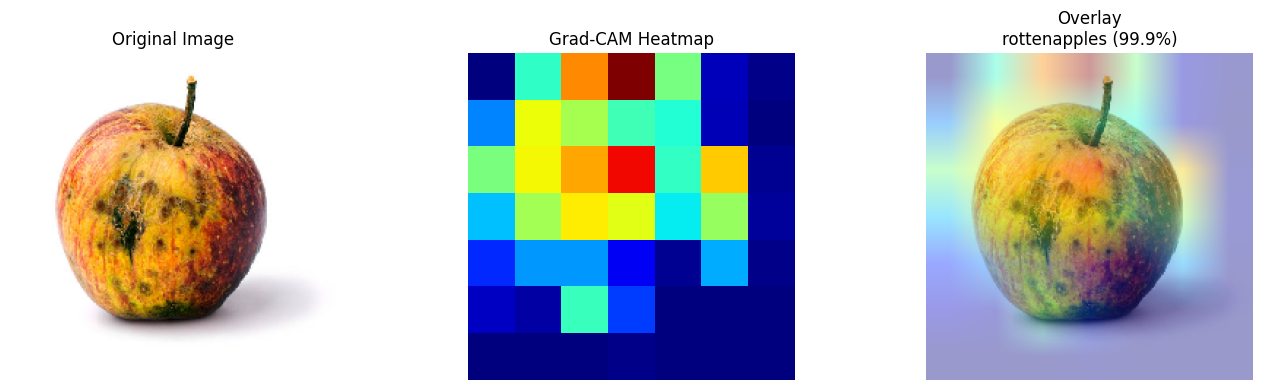

In [ ]:
# ── Step 4: Visualize it ─────────────────────────────────────

def show_gradcam(img_path, model, grad_model, class_names):
    
    orig, heatmap, overlay, pred_class, confidence = get_gradcam_heatmap(
        img_path, model, grad_model, class_names
    )

    fig, axes = plt.subplots(1, 3, figsize=(14, 4))

    axes[0].imshow(orig)
    axes[0].set_title("Original Image")
    axes[0].axis("off")

    axes[1].imshow(heatmap, cmap='jet')
    axes[1].set_title("Grad-CAM Heatmap")
    axes[1].axis("off")

    axes[2].imshow(overlay)
    axes[2].set_title(f"Overlay\n{pred_class} ({confidence:.1f}%)")
    axes[2].axis("off")

    plt.tight_layout()
    plt.show()

# ── Run it on your test images ────────────────────────────────
class_names = ['freshapples', 'freshbanana', 'freshoranges', 
               'rottenapples', 'rottenbanana', 'rottenoranges']

show_gradcam(
    "..\Test_Images\sample-apple.jpg",
    model,
    grad_model,
    class_names
)